In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


In [ ]:
#Running this will read the AI4I Predictive Maintenance dataset
AI4I = pd.read_csv("../data/ai4i2020.csv")

In [ ]:
AI4I

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
AI4I = AI4I.drop(columns = ["TWF", "HDF", "PWF", "OSF", "RNF"])

We can see from the above output that there are a total of 1000 observations in this dataset and 14 variables.

In [ ]:
#Using info() to check whether there are missing values in the columns of this dataset
AI4I.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


There are no missing values in any of the columns. This is great because now we do not have worry about removing rows/columns or performing any type of imputation.

In [ ]:
#Using describe() to get an understanding of the various descriptive statistics like mean, standard deviation, max, etc.
AI4I.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


This gives us important information about the maximum values for the various continuous variables

Some of the values are abbreviated in this dataset. It is important to understand the meaning of these values. Therefore, let's replace these to understand our dataset better.

In [ ]:
AI4I["Type"] = AI4I["Type"].replace({"M":"Medium quality", "L":"Low quality", "H":"High quality"})

In [ ]:
AI4I

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,Medium quality,298.1,308.6,1551,42.8,0,0
1,2,L47181,Low quality,298.2,308.7,1408,46.3,3,0
2,3,L47182,Low quality,298.1,308.5,1498,49.4,5,0
3,4,L47183,Low quality,298.2,308.6,1433,39.5,7,0
4,5,L47184,Low quality,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,Medium quality,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,High quality,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,Medium quality,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,High quality,299.0,308.7,1408,48.5,25,0


It seems like we would not need the first columns: UDI and Product ID. Therefore, let's remove these two from dataset.

In [ ]:
AI4I = AI4I.drop(columns = ["UDI", "Product ID"])

In [ ]:
AI4I

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,Medium quality,298.1,308.6,1551,42.8,0,0
1,Low quality,298.2,308.7,1408,46.3,3,0
2,Low quality,298.1,308.5,1498,49.4,5,0
3,Low quality,298.2,308.6,1433,39.5,7,0
4,Low quality,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,Medium quality,298.8,308.4,1604,29.5,14,0
9996,High quality,298.9,308.4,1632,31.8,17,0
9997,Medium quality,299.0,308.6,1645,33.4,22,0
9998,High quality,299.0,308.7,1408,48.5,25,0


Now, let's create binary values for the categorical variable: Type

In [ ]:
AI4I = pd.get_dummies(AI4I, columns = ["Type"], drop_first = True)

This is the right time to divide the dataset into feature and target

In [ ]:
feature = AI4I.drop(columns = ["Machine failure"])
target = pd.DataFrame(AI4I["Machine failure"])

Let's remove "[ ]"

In [ ]:
feature.columns = feature.columns.str.replace("[", "", regex = False)
feature.columns = feature.columns.str.replace("]", "", regex = False)
feature.columns = feature.columns.str.replace(" ", "_", regex = False)

In [ ]:
feature

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_Low_quality,Type_Medium_quality
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False
...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,False,True
9996,298.9,308.4,1632,31.8,17,False,False
9997,299.0,308.6,1645,33.4,22,False,True
9998,299.0,308.7,1408,48.5,25,False,False


In [ ]:
target

,Machine failure
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


Train-Test split the datasets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size = 0.2, stratify = target, random_state = 42)

Train the model

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (
    (y_train['Machine failure'] == 0).sum() /
    (y_train['Machine failure'] == 1).sum()
)

model = XGBClassifier(n_estimators = 100, max_depth = 4, learning_rate = 0.1, n_jobs = -1, scale_pos_weight=scale_pos_weight, use_label_encoder = False, eval_metric = 'logloss')

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

Let's make predictions now

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.75
y_pred_thresh = (y_prob > threshold).astype(int)

Let's evaluate the model

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))

[[1900   32]
 [  13   55]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.81      0.71        68

    accuracy                           0.98      2000
   macro avg       0.81      0.90      0.85      2000
weighted avg       0.98      0.98      0.98      2000



Let's plot

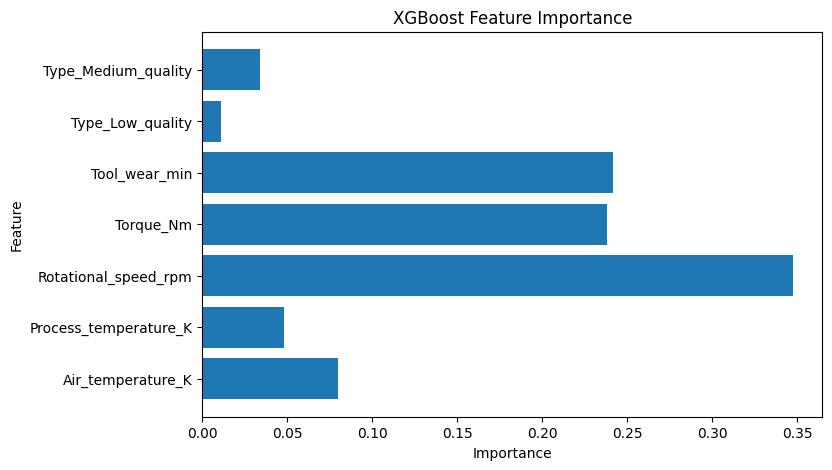

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(feature.columns, importances)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()